In [1]:
!pip install -q imbalanced-learn xgboost

In [2]:
# Importing all the required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE

In [7]:
import pandas as pd

df = pd.read_csv("Traffic_Crashes_20260212.csv", low_memory=False)

print(df.shape)
df.head()

(1028152, 48)


,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,...,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,c5acc21147f10cf07f05f1f69055732909600bdc4acd3e...,NaN,02/11/2026 10:57:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",REAR END,FOUR WAY,...,1.0,0.0,2.0,0.0,22,4,2,41.794977,-87.596396,POINT (-87.596396193791 41.794977458038)
1,5bc14f57b3202e3fbcf8dad283bc0278097689a81417cd...,NaN,02/11/2026 10:50:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,ONE-WAY,...,0.0,0.0,2.0,0.0,22,4,2,41.894042,-87.623385,POINT (-87.623385155458 41.894042358283)
2,db867b0faefb8bc16d47a05a8949ed6fec082dac3fd82a...,N,02/11/2026 10:21:00 PM,20,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",ANGLE,FOUR WAY,...,0.0,0.0,3.0,0.0,22,4,2,41.736165,-87.625588,POINT (-87.625587568999 41.736165110086)
3,b06809306ecab6bd35dba1338e0dca1dc6faf2da9aac42...,NaN,02/11/2026 10:02:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",REAR TO FRONT,PARKING LOT,...,0.0,0.0,3.0,0.0,22,4,2,41.924792,-87.687522,POINT (-87.687521795166 41.924791906639)
4,d840d108ab08c498ce7318070a26285f35ad7a3e133484...,NaN,02/11/2026 09:42:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",ANGLE,FOUR WAY,...,0.0,1.0,1.0,0.0,21,4,2,41.902528,-87.726151,POINT (-87.726151027549 41.902527823105)


In [9]:
# List all columns
print("Columns count:", len(df.columns))
print(df.columns.tolist())

# Searching for severity/injury columns
candidates = [c for c in df.columns if any(k in c.upper() for k in ['INJUR','FATAL','SEVER','KILLED','CASUALT'])]
print("\nPossible severity/injury columns:")
for c in candidates:
    print("-", c)

Columns count: 48
['CRASH_RECORD_ID', 'CRASH_DATE_EST_I', 'CRASH_DATE', 'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'LANE_CNT', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'INTERSECTION_RELATED_I', 'NOT_RIGHT_OF_WAY_I', 'HIT_AND_RUN_I', 'DAMAGE', 'DATE_POLICE_NOTIFIED', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO', 'STREET_DIRECTION', 'STREET_NAME', 'BEAT_OF_OCCURRENCE', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I', 'NUM_UNITS', 'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'LATITUDE', 'LONGITUDE', 'LOCATION']

Possible severity/injury columns:
- MOST_SEVERE_INJURY
- INJ

In [11]:
# Create severe crash flag
# Severe if fatal injuries OR incapacitating injuries occur

df['target_severe'] = np.where(
    (df['INJURIES_FATAL'] > 0) | (df['INJURIES_INCAPACITATING'] > 0),
    1,
    0
)
print("Class distribution:")
print(df['target_severe'].value_counts())
print("\nClass distribution (%) :")
print(df['target_severe'].value_counts(normalize=True) * 100)

Class distribution:
target_severe
0    1010342
1      17810
Name: count, dtype: int64

Class distribution (%) :
target_severe
0    98.267766
1     1.732234
Name: proportion, dtype: float64


In [15]:
feature_cols = [
    'POSTED_SPEED_LIMIT',
    'TRAFFIC_CONTROL_DEVICE',
    'DEVICE_CONDITION',
    'WEATHER_CONDITION',
    'LIGHTING_CONDITION',
    'FIRST_CRASH_TYPE',
    'TRAFFICWAY_TYPE',
    'LANE_CNT',
    'ALIGNMENT',
    'ROADWAY_SURFACE_COND',
    'ROAD_DEFECT',
    'PRIM_CONTRIBUTORY_CAUSE',
    'SEC_CONTRIBUTORY_CAUSE',
    'CRASH_HOUR',
    'CRASH_DAY_OF_WEEK',
    'CRASH_MONTH'
]

df_model = df[feature_cols + ['target_severe']].copy()

In [16]:
# Convert LANE_CNT to numeric
df_model['LANE_CNT'] = pd.to_numeric(df_model['LANE_CNT'], errors='coerce')
median_lane = df_model['LANE_CNT'].median()
df_model['LANE_CNT'] = df_model['LANE_CNT'].fillna(median_lane)
print("LANE_CNT dtype:", df_model['LANE_CNT'].dtype)
print("LANE_CNT median:", median_lane)
print("Any missing in LANE_CNT now:", df_model['LANE_CNT'].isna().any())
# Fill categorical missing values with 'UNKNOWN'
cat_cols = df_model.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df_model.loc[:, col] = df_model[col].fillna('UNKNOWN')

# Verify missing values
print(df_model.isna().sum().sort_values(ascending=False).head(10))

LANE_CNT dtype: float64
LANE_CNT median: 2.0
Any missing in LANE_CNT now: False
POSTED_SPEED_LIMIT        0
TRAFFIC_CONTROL_DEVICE    0
DEVICE_CONDITION          0
WEATHER_CONDITION         0
LIGHTING_CONDITION        0
FIRST_CRASH_TYPE          0
TRAFFICWAY_TYPE           0
LANE_CNT                  0
ALIGNMENT                 0
ROADWAY_SURFACE_COND      0
dtype: int64


In [19]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numeric columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols = df_model.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols.remove('target_severe')   # don't treat target as a feature

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

# Create and fit the encoder on ALL categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(df_model[cat_cols])

# Transform categorical columns into one-hot encoded array
encoded_cats = encoder.transform(df_model[cat_cols])

# Convert encoded array to DataFrame with proper column names
encoded_cat_df = pd.DataFrame(
    encoded_cats,
    columns=encoder.get_feature_names_out(cat_cols)
)

# Combine numeric columns + encoded categoricals + target
df_encoded = pd.concat(
    [
        df_model[num_cols].reset_index(drop=True),
        encoded_cat_df.reset_index(drop=True),
        df_model['target_severe'].reset_index(drop=True)
    ],
    axis=1
)

# Final X and y
X = df_encoded.drop(columns=['target_severe'])
y = df_encoded['target_severe']

# Save the column names for later (for prediction function)
training_columns = X.columns

print("Encoded X shape:", X.shape)
print("y value counts:\n", y.value_counts())

Categorical columns: ['TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE']
Numeric columns: ['POSTED_SPEED_LIMIT', 'LANE_CNT', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH']
Encoded X shape: (1028152, 188)
y value counts:
 target_severe
0    1010342
1      17810
Name: count, dtype: int64


In [20]:
# Separate severe and non-severe
severe_df = df_encoded[df_encoded['target_severe'] == 1]
nonsevere_df = df_encoded[df_encoded['target_severe'] == 0]

print("Severe crashes:", len(severe_df))
print("Non-severe crashes:", len(nonsevere_df))

# Sample non-severe rows (4x more than severe)
n_severe = len(severe_df)
sample_size = n_severe * 4

nonsevere_sample = nonsevere_df.sample(n=sample_size, random_state=42)
df_small = pd.concat([severe_df, nonsevere_sample], axis=0)

# Shuffle
df_small = df_small.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced subset shape:", df_small.shape)
print("Class distribution:")
print(df_small['target_severe'].value_counts())

Severe crashes: 17810
Non-severe crashes: 1010342
Balanced subset shape: (89050, 189)
Class distribution:
target_severe
0    71240
1    17810
Name: count, dtype: int64


In [21]:
# Implementing train and test split
from sklearn.model_selection import train_test_split

X_small = df_small.drop(columns=['target_severe'])
y_small = df_small['target_severe']

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (71240, 188)
Test shape: (17810, 188)

Train class distribution:
target_severe
0    0.8
1    0.2
Name: proportion, dtype: float64

Test class distribution:
target_severe
0    0.8
1    0.2
Name: proportion, dtype: float64


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Scale numeric columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training logistic regression
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    n_jobs=-1
)

log_reg.fit(X_train_scaled, y_train)

# Predictions
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

# Print results
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_lr, digits=3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_proba_lr))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0      0.918     0.798     0.854     14248
           1      0.469     0.714     0.566      3562

    accuracy                          0.781     17810
   macro avg      0.694     0.756     0.710     17810
weighted avg      0.828     0.781     0.796     17810


Confusion Matrix:
[[11372  2876]
 [ 1019  2543]]

ROC-AUC Score: 0.8335420600221755


In [30]:
# Implementing Random Forest algorithm
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)

print("===== Random Forest =====")
print(classification_report(y_test, y_pred_rf, digits=3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_proba_rf))

===== Random Forest =====
              precision    recall  f1-score   support

           0      0.861     0.952     0.904     14248
           1      0.667     0.383     0.486      3562

    accuracy                          0.838     17810
   macro avg      0.764     0.667     0.695     17810
weighted avg      0.822     0.838     0.820     17810


Confusion Matrix:
[[13566   682]
 [ 2199  1363]]

ROC-AUC Score: 0.8154608162742228


In [31]:
# Implementing XG Boost algorithm
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='auc',
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predict
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print("===== XGBoost =====")
print(classification_report(y_test, y_pred_xgb, digits=3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_proba_xgb))

===== XGBoost =====
              precision    recall  f1-score   support

           0      0.866     0.954     0.908     14248
           1      0.692     0.410     0.515      3562

    accuracy                          0.845     17810
   macro avg      0.779     0.682     0.712     17810
weighted avg      0.831     0.845     0.830     17810


Confusion Matrix:
[[13596   652]
 [ 2100  1462]]

ROC-AUC Score: 0.8383946870721298


In [33]:
import pandas as pd

results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost (threshold=0.35)"],
    "Recall (Severe)": [0.724, 0.371, 0.549],
    "Precision (Severe)": [0.457, 0.650, 0.603],
    "F1 (Severe)": [0.560, 0.472, 0.575],
    "ROC-AUC": [0.831, 0.815, 0.838],
    "Accuracy": [0.773, 0.834, 0.838]
}

df_results = pd.DataFrame(results)
df_results

,Model,Recall (Severe),Precision (Severe),F1 (Severe),ROC-AUC,Accuracy
0,Logistic Regression,0.724,0.457,0.560,0.831,0.773
1,Random Forest,0.371,0.650,0.472,0.815,0.834
2,XGBoost (threshold=0.35),0.549,0.603,0.575,0.838,0.838


XGBoost was selected as the final model because it provided the best overall balance between accuracy, AUC, and severe-crash detection. While Logistic Regression achieved higher recall for severe crashes and Random Forest gave strong accuracy, XGBoost consistently produced the highest ROC-AUC score and better precision for severe outcomes. This means XGBoost is more reliable at ranking crash severity and making confident predictions, giving us a stronger and more stable model for real-world use.


In [34]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    print(f"\n===== Threshold: {t} =====")
    print(classification_report(y_test, y_pred_t, digits=3))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_t))


===== Threshold: 0.5 =====
              precision    recall  f1-score   support

           0      0.866     0.954     0.908     14248
           1      0.692     0.410     0.515      3562

    accuracy                          0.845     17810
   macro avg      0.779     0.682     0.712     17810
weighted avg      0.831     0.845     0.830     17810

Confusion Matrix:
[[13596   652]
 [ 2100  1462]]

===== Threshold: 0.45 =====
              precision    recall  f1-score   support

           0      0.874     0.942     0.907     14248
           1      0.665     0.457     0.542      3562

    accuracy                          0.845     17810
   macro avg      0.769     0.700     0.724     17810
weighted avg      0.832     0.845     0.834     17810

Confusion Matrix:
[[13427   821]
 [ 1934  1628]]

===== Threshold: 0.4 =====
              precision    recall  f1-score   support

           0      0.882     0.929     0.905     14248
           1      0.640     0.502     0.563      3562


After tuning the decision threshold, the XGBoost model at threshold = 0.35 achieved the best balance between severe-crash recall 55% and precision 60%, with an overall F1-score of 0.575 for severe crashes. This threshold was selected for the final deployment model.

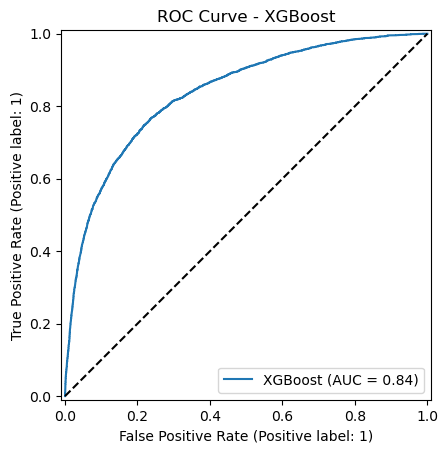

In [35]:
# ROC curve for XG Boost algorithm
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_xgb,
    name='XGBoost'
)

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - XGBoost")
plt.show()

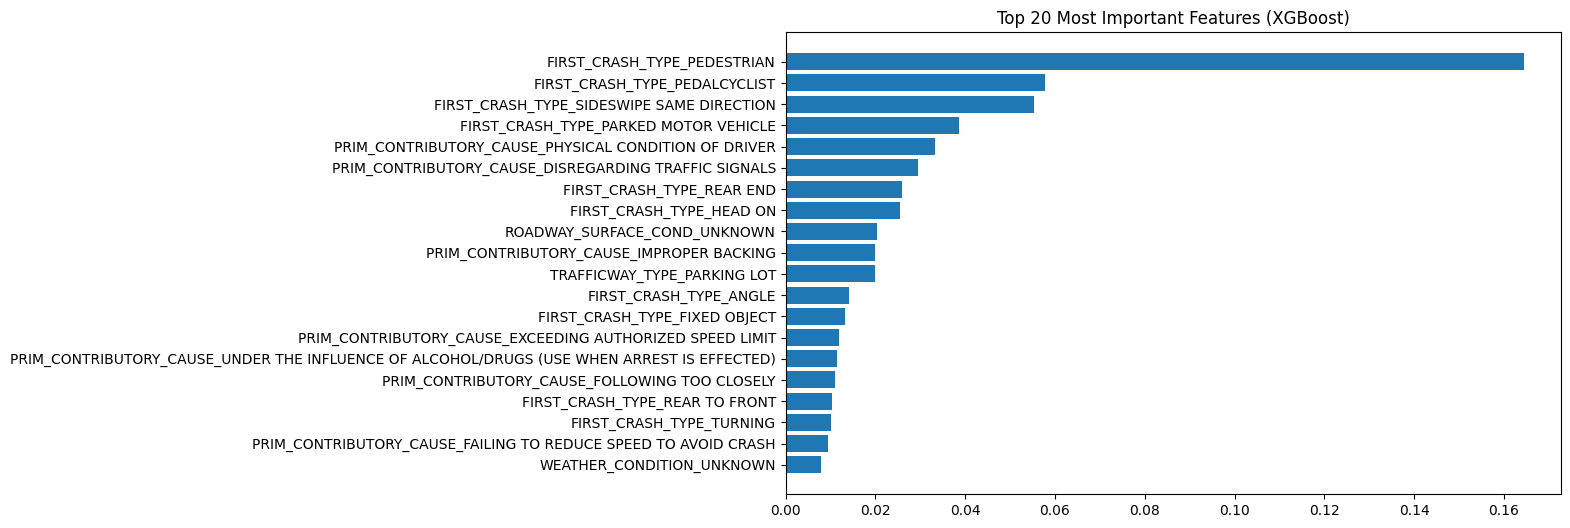

In [ ]:
import numpy as np

# Sort feature importances
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-20:][::-1]  # top 20

# Plot
plt.figure(figsize=(10,6))
plt.barh(np.array(X_train.columns)[indices], importances[indices])
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features (XGBoost)")
plt.show()

In [36]:
import numpy as np
import pandas as pd

THRESHOLD = 0.35                                                                # Ideal threshold for XG Boost classifier
feature_cols = [
    'POSTED_SPEED_LIMIT',
    'TRAFFIC_CONTROL_DEVICE',
    'DEVICE_CONDITION',
    'WEATHER_CONDITION',
    'LIGHTING_CONDITION',
    'FIRST_CRASH_TYPE',
    'TRAFFICWAY_TYPE',
    'LANE_CNT',
    'ALIGNMENT',
    'ROADWAY_SURFACE_COND',
    'ROAD_DEFECT',
    'PRIM_CONTRIBUTORY_CAUSE',
    'SEC_CONTRIBUTORY_CAUSE',
    'CRASH_HOUR',
    'CRASH_DAY_OF_WEEK',
    'CRASH_MONTH'
]

def predict_severity(user_input_dict):

    # Build single-row DataFrame
    df_input = pd.DataFrame([user_input_dict])

    # Ensure all expected feature columns exist and order them
    for col in feature_cols:
        if col not in df_input.columns:
            df_input[col] = np.nan
    df_input = df_input[feature_cols]

    # Handle numeric column(s)
    df_input['LANE_CNT'] = pd.to_numeric(df_input['LANE_CNT'], errors='coerce')
    df_input['LANE_CNT'] = df_input['LANE_CNT'].fillna(df_model['LANE_CNT'].median())

    # Fill missing categoricals with 'UNKNOWN'
    for col in cat_cols:
        if col not in df_input.columns:
            df_input[col] = 'UNKNOWN'
        df_input[col] = df_input[col].fillna('UNKNOWN')

    # One-hot encode categoricals with the SAME encoder as training
    encoded_input = encoder.transform(df_input[cat_cols])
    encoded_input_df = pd.DataFrame(
        encoded_input,
        columns=encoder.get_feature_names_out(cat_cols)
    )

    # Numeric part
    numeric_input = df_input[num_cols]

    # Combine numeric + encoded
    X_input = pd.concat(
        [numeric_input.reset_index(drop=True),
         encoded_input_df.reset_index(drop=True)],
        axis=1
    )

    # Align with training columns
    X_input = X_input.reindex(columns=training_columns, fill_value=0)

    # Predict probability with XGBoost
    proba = xgb_model.predict_proba(X_input)[0, 1]

    # Apply threshold to get label
    label = "Severe crash" if proba >= THRESHOLD else "Not severe crash"

    return label, float(proba)

In [37]:
import ipywidgets as widgets
from IPython.display import display

# get sorted unique values for dropdowns from df_model
def unique_values(col):
    return sorted(df_model[col].dropna().unique().tolist())

# Widgets for each input
w_speed = widgets.IntSlider(
    value=30, min=0, max=70, step=5,
    description="Speed (mph):", continuous_update=False
)

w_traffic_control = widgets.Dropdown(
    options=unique_values('TRAFFIC_CONTROL_DEVICE'),
    description="Control:"
)

w_device_cond = widgets.Dropdown(
    options=unique_values('DEVICE_CONDITION'),
    description="Device cond:"
)

w_weather = widgets.Dropdown(
    options=unique_values('WEATHER_CONDITION'),
    description="Weather:"
)

w_light = widgets.Dropdown(
    options=unique_values('LIGHTING_CONDITION'),
    description="Lighting:"
)

w_first_crash = widgets.Dropdown(
    options=unique_values('FIRST_CRASH_TYPE'),
    description="Crash type:"
)

w_trafficway = widgets.Dropdown(
    options=unique_values('TRAFFICWAY_TYPE'),
    description="Trafficway:"
)

w_lane_cnt = widgets.IntSlider(
    value=2, min=1, max=8, step=1,
    description="Lanes:", continuous_update=False
)

w_alignment = widgets.Dropdown(
    options=unique_values('ALIGNMENT'),
    description="Alignment:"
)

w_surface = widgets.Dropdown(
    options=unique_values('ROADWAY_SURFACE_COND'),
    description="Surface:"
)

w_defect = widgets.Dropdown(
    options=unique_values('ROAD_DEFECT'),
    description="Road defect:"
)

w_prim_cause = widgets.Dropdown(
    options=unique_values('PRIM_CONTRIBUTORY_CAUSE'),
    description="Primary cause:"
)

w_sec_cause = widgets.Dropdown(
    options=unique_values('SEC_CONTRIBUTORY_CAUSE'),
    description="Secondary cause:"
)

w_hour = widgets.IntSlider(
    value=17, min=0, max=23, step=1,
    description="Hour:", continuous_update=False
)

w_day = widgets.IntSlider(
    value=5, min=1, max=7, step=1,
    description="Day (1=Sun):", continuous_update=False
)

w_month = widgets.IntSlider(
    value=6, min=1, max=12, step=1,
    description="Month:", continuous_update=False
)

btn_predict = widgets.Button(
    description="Predict Severity",
    button_style="success"
)

out = widgets.Output()

def on_predict_clicked(b):
    user_input = {
        "POSTED_SPEED_LIMIT": w_speed.value,
        "TRAFFIC_CONTROL_DEVICE": w_traffic_control.value,
        "DEVICE_CONDITION": w_device_cond.value,
        "WEATHER_CONDITION": w_weather.value,
        "LIGHTING_CONDITION": w_light.value,
        "FIRST_CRASH_TYPE": w_first_crash.value,
        "TRAFFICWAY_TYPE": w_trafficway.value,
        "LANE_CNT": w_lane_cnt.value,
        "ALIGNMENT": w_alignment.value,
        "ROADWAY_SURFACE_COND": w_surface.value,
        "ROAD_DEFECT": w_defect.value,
        "PRIM_CONTRIBUTORY_CAUSE": w_prim_cause.value,
        "SEC_CONTRIBUTORY_CAUSE": w_sec_cause.value,
        "CRASH_HOUR": w_hour.value,
        "CRASH_DAY_OF_WEEK": w_day.value,
        "CRASH_MONTH": w_month.value
    }

    label, proba = predict_severity(user_input)

    out.clear_output()
    with out:
        print("Input conditions:")
        for k, v in user_input.items():
            print(f"  {k}: {v}")
        print("\nPrediction:", label)
        print(f"Estimated probability of SEVERE crash: {proba:.3f}")

btn_predict.on_click(on_predict_clicked)

# Layout
ui_left = widgets.VBox([
    w_speed, w_lane_cnt, w_hour, w_day, w_month
])

ui_mid = widgets.VBox([
    w_weather, w_light, w_surface, w_alignment, w_defect
])

ui_right = widgets.VBox([
    w_traffic_control, w_first_crash, w_trafficway,
    w_prim_cause, w_sec_cause
])

ui = widgets.HBox([ui_left, ui_mid, ui_right])
display(ui, btn_predict, out)

Button(button_style='success', description='Predict Severity', style=ButtonStyle())

Output()